In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATASET = 'https://raw.githubusercontent.com/danilmisterio-prog/ABCXYZ/refs/heads/main/abc_xyz_dataset.csv'
df = pd.read_csv(DATASET)
df.head()

,Item_ID,Item_Name,Category,Jan_Demand,Feb_Demand,Mar_Demand,Apr_Demand,May_Demand,Jun_Demand,Jul_Demand,Aug_Demand,Sep_Demand,Oct_Demand,Nov_Demand,Dec_Demand,Total_Annual_Units,Price_Per_Unit,Total_Sales_Value
0,ITM_001,Surface Near,Grocery,4516,4069,4664,4653,4508,4125,4669,4210,4824,4497,4259,4782,53776,10,537760
1,ITM_002,Central Him,Grocery,4792,4964,4628,4660,4897,5015,4805,4686,4896,4536,4520,5054,57453,100,5745300
2,ITM_003,Win Everyone,Apparel,61,175,38,43,15,161,224,41,387,340,70,21,1576,2,3152
3,ITM_004,Task Save,Apparel,1145,1113,717,832,783,954,1047,894,994,978,1136,712,11305,2,22610
4,ITM_005,Hotel Teacher,Grocery,1494,2051,1400,1918,1669,1733,1695,1560,1679,1381,1591,1662,19833,10,198330


In [2]:
df = df.sort_values('Total_Sales_Value', ascending=False)
df

,Item_ID,Item_Name,Category,Jan_Demand,Feb_Demand,Mar_Demand,Apr_Demand,May_Demand,Jun_Demand,Jul_Demand,Aug_Demand,Sep_Demand,Oct_Demand,Nov_Demand,Dec_Demand,Total_Annual_Units,Price_Per_Unit,Total_Sales_Value
924,ITM_925,Ten And,Grocery,4991,4663,5068,4885,5127,4705,5130,5129,5127,4840,4774,5023,59462,1000,59462000
511,ITM_512,Radio Race,Grocery,4185,4087,3660,3774,4391,3906,3699,4155,3936,3646,3959,4208,47606,1000,47606000
521,ITM_522,Pattern Book,Grocery,3079,3185,3081,2794,3313,3329,3168,3241,3309,2997,2781,2859,37136,1000,37136000
394,ITM_395,Animal Key,Grocery,5180,4626,5010,4802,4856,5361,5504,4910,4631,4959,4867,4903,59609,500,29804500
168,ITM_169,Material Vote,Grocery,4871,4994,4740,4958,4428,4889,4754,4672,4477,4544,4553,4982,56862,500,28431000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,ITM_178,Investment Agreement,Electronics,63,63,59,72,55,65,60,59,59,61,75,65,756,2,1512
482,ITM_483,Along Have,Home & Kitchen,45,53,76,60,51,69,60,57,60,76,56,65,728,2,1456
408,ITM_409,Indicate Organization,Home & Kitchen,53,53,70,62,55,54,58,69,62,48,54,60,698,2,1396
568,ITM_569,Worry Because,Toys,50,65,61,60,51,55,48,51,54,55,50,45,645,2,1290


In [3]:
df['Sales_value_share'] = df['Total_Sales_Value'] / df['Total_Sales_Value'].sum()
df['Sales_value_share']

,Sales_value_share
924,0.055453
511,0.044397
521,0.034632
394,0.027795
168,0.026514
...,...
177,0.000001
482,0.000001
408,0.000001
568,0.000001


In [4]:
df = df.sort_values('Sales_value_share', ascending=False)

df['Aggregated_share'] = df['Sales_value_share'].cumsum()

df['Aggregated_share']

,Aggregated_share
924,0.055453
511,0.099850
521,0.134483
394,0.162278
168,0.188792
...,...
177,0.999995
482,0.999996
408,0.999998
568,0.999999


In [5]:
df['ABC'] = pd.cut(
    df['Aggregated_share'], bins = [0, 0.80, 0.95, 1.01], labels=['A', 'B', 'C']
)

df['ABC']

,ABC
924,A
511,A
521,A
394,A
168,A
...,...
177,C
482,C
408,C
568,C


In [28]:
abc = df.groupby('ABC')['ABC'].count().reset_index(name='Number of values')

abc['Share_of_ABC_values'] = abc['Number of values'] / abc['Number of values'].sum()
abc

/tmp/ipykernel_6124/796078619.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  abc = df.groupby('ABC')['ABC'].count().reset_index(name='Number of values')


,ABC,Number of values,Share_of_ABC_values
0,A,87,0.087
1,B,170,0.170
2,C,743,0.743


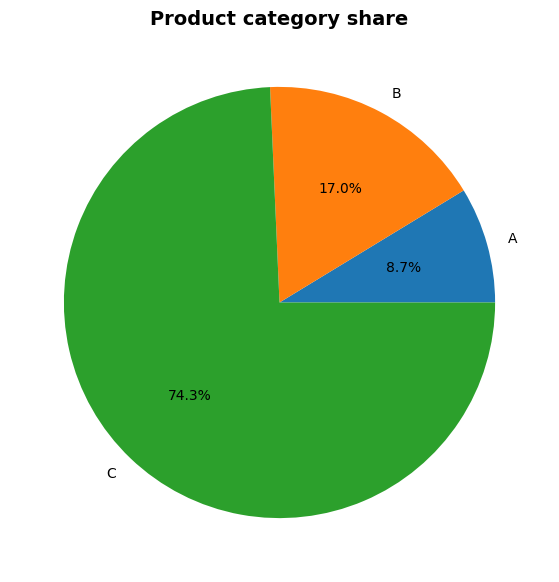

In [34]:
plt.figure(figsize=(14, 7))

pie = plt.pie(
    abc['Share_of_ABC_values'],
    labels=abc['ABC'],
    autopct="%1.1f%%"
)

plt.title('Product category share', weight = 'bold', fontsize = 14)

plt.show()

In [8]:
df['MEAN'] = df['Total_Annual_Units'] / 12
df['MEAN'] = df['MEAN'].round(0)
df['MEAN']

,MEAN
924,4955.0
511,3967.0
521,3095.0
394,4967.0
168,4738.0
...,...
177,63.0
482,61.0
408,58.0
568,54.0


In [11]:
df['STD'] = df[['Jan_Demand',	'Feb_Demand',	'Mar_Demand',	'Apr_Demand',	'May_Demand',	'Jun_Demand',	'Jul_Demand',	'Aug_Demand',	'Sep_Demand',	'Oct_Demand',	'Nov_Demand',	'Dec_Demand']].std(axis=1)
df['STD']

,STD
924,175.138300
511,242.380930
521,199.492234
394,265.766972
168,203.303848
...,...
177,5.704862
482,9.499601
408,6.685579
568,5.832900


In [12]:
df['Variation_Ratio'] = df['STD'] / df['MEAN']
df['Variation_Ratio']

,Variation_Ratio
924,0.035346
511,0.061099
521,0.064456
394,0.053507
168,0.042909
...,...
177,0.090553
482,0.155731
408,0.115269
568,0.108017


In [13]:
df = df.sort_values('Variation_Ratio', ascending=False)
df['XYZ'] = pd.cut(df['Variation_Ratio'], bins = [-0.1, 0.1, 0.25, df['Variation_Ratio'].max()], labels=['X', 'Y', 'Z'])
df['XYZ']

,XYZ
972,Z
873,Z
497,Z
2,Z
381,Z
...,...
218,X
457,X
446,X
35,X


In [38]:
xyz = df.groupby('XYZ')['XYZ'].count().reset_index(name = 'Number_of_XYZ_values')
xyz['Share_of_XYZ_values'] = xyz['Number_of_XYZ_values'] / xyz['Number_of_XYZ_values'].sum()

xyz

/tmp/ipykernel_6124/2293545500.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xyz = df.groupby('XYZ')['XYZ'].count().reset_index(name = 'Number_of_XYZ_values')


,XYZ,Number_of_XYZ_values,Share_of_XYZ_values
0,X,637,0.637
1,Y,216,0.216
2,Z,147,0.147


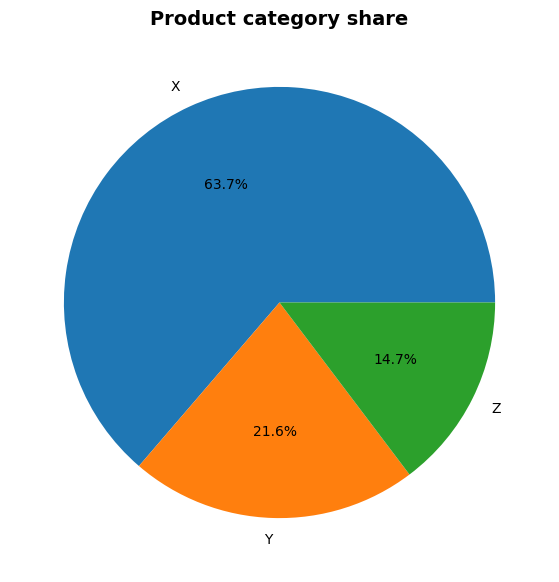

In [40]:
plt.figure(figsize=(14, 7))

pie = plt.pie(
    xyz['Share_of_XYZ_values'],
    labels=xyz['XYZ'],
    autopct="%1.1f%%"
)

plt.title('Product category share', weight = 'bold', fontsize = 14)

plt.show()

In [16]:
def classify_demand(row):
    abc = row['ABC']
    xyz = row['XYZ']

    if (abc == 'A' and xyz == 'X') or (abc == 'A' and xyz == 'Y'):
        return 'High value, Stable demand'
    elif (abc == 'A' and xyz == 'Z') or (abc == 'B' and xyz == 'Z'):
        return 'High value, Unpredictable demand'
    elif (abc == 'C' and xyz == 'X') or (abc == 'C' and xyz == 'Y'):
        return 'Low value, Stable demand'
    elif (abc == 'C' and xyz == 'Z'):
        return 'Low value, Unpredictable demand'
    return None

df['ABCXYZ'] = df.apply(classify_demand, axis=1)

df['ABCXYZ']

,ABCXYZ
972,"Low value, Unpredictable demand"
873,"Low value, Unpredictable demand"
497,"Low value, Unpredictable demand"
2,"Low value, Unpredictable demand"
381,"Low value, Unpredictable demand"
...,...
218,"High value, Stable demand"
457,"Low value, Stable demand"
446,"High value, Stable demand"
35,"Low value, Stable demand"


In [18]:
df['ABCXYZ'].value_counts()

,count
ABCXYZ,
"Low value, Stable demand",615
"Low value, Unpredictable demand",128
"High value, Stable demand",84
"High value, Unpredictable demand",19


In [43]:
final = df.groupby('ABCXYZ')['ABCXYZ'].count().reset_index(name='Number_of_product')
final['Share_of_group'] = final['Number_of_product'] / final['Number_of_product'].sum()

final

,ABCXYZ,Number_of_product,Share_of_group
0,"High value, Stable demand",84,0.099291
1,"High value, Unpredictable demand",19,0.022459
2,"Low value, Stable demand",615,0.726950
3,"Low value, Unpredictable demand",128,0.151300


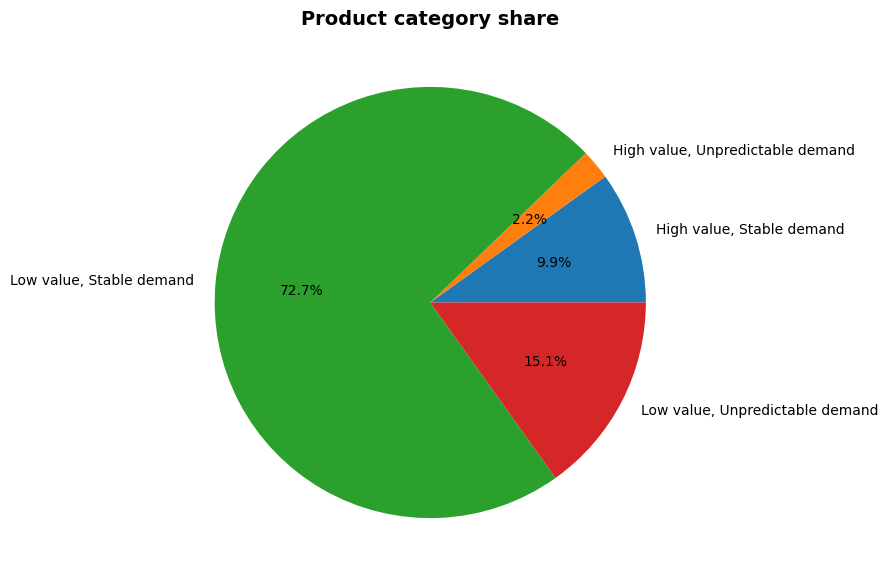

In [44]:
plt.figure(figsize=(14, 7))

pie = plt.pie(
    final['Share_of_group'],
    labels=final['ABCXYZ'],
    autopct="%1.1f%%"
)

plt.title('Product category share', weight = 'bold', fontsize = 14)

plt.show()

In [20]:
abc_map = {'A': 3, 'B': 2, 'C': 1}
xyz_map = {'X': 3, 'Y': 2, 'Z': 1}

df["ABC RANK"] = df['ABC'].map(abc_map).astype(int)
df['XYZ RANK'] = df['XYZ'].map(xyz_map).astype(int)

df['Total rank'] = df['ABC RANK'] + df ['XYZ RANK']

df['Total rank']


,Total rank
972,2
873,2
497,2
2,2
381,2
...,...
218,6
457,4
446,6
35,4


In [21]:
df['Total rank'].value_counts()

,count
Total rank,
4,501
3,173
5,133
2,128
6,65


In [22]:
df.to_csv('ABC XYZ analysis')

## Conclusion

The **ABC-XYZ analysis** successfully segmented products according to their contribution to total sales and demand stability, providing a clear framework for inventory management and decision-making.

### Key Findings

- **AX and AY** products represent the most valuable inventory items. They generate the highest share of revenue while maintaining stable or moderately stable demand, making them the highest priority for inventory control.
- **AZ and BZ** products contribute significantly to revenue but exhibit irregular demand. These categories require demand forecasting, safety stock, and frequent inventory monitoring to reduce the risk of stockouts or excess inventory.
- **BX and BY** products have medium business importance and can be managed using standard replenishment strategies.
- **CX and CY** products have a relatively small impact on total sales and stable demand, allowing for simplified inventory management.
- **CZ** products combine low sales contribution with highly unpredictable demand. These items should be reviewed regularly to determine whether inventory levels should be reduced or the products should be discontinued.

### Business Value

The ABC-XYZ analysis demonstrates how combining product profitability with demand variability leads to more effective inventory management. This approach helps businesses prioritize high-value products, optimize stock levels, reduce storage costs, improve forecasting accuracy, and allocate resources more efficiently.

Overall, this project demonstrates the practical application of data analysis techniques for inventory optimization and supports data-driven business decisions.